# COMP4131 - Data Modelling and Analysis - Coursework 2
# House Price Prediction using Machine Learning

## 1. Introduction

This notebook explores a housing dataset and aims to understand the relationships between housing features and price.

## Import Libraries

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

# Settings
sns.set(style="whitegrid")

## 2. Load Dataset

The dataset is loaded from a local file. The file should be placed in the same directory as this notebook.

In [ ]:
# Load dataset
df_original = pd.read_csv("data.csv")
df = df_original.copy()
df_original.head()
# 改introduction 里面的 个数

(4600, 18)

## 3. Data Overview
第二三部分 合并
This section provides an overview of the dataset structure, including the number of rows, columns, and data types.

In [ ]:

df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


## 4. Missing Value Analysis

This section examines missing values in the dataset to identify potential data quality issues.

In [5]:
# 1. Calculate the missing values and their percentages.
null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100

# Show columns with missing values
missing_summary = pd.concat([null_counts, null_percent], axis=1, keys=['Total', 'Percentage'])
missing_summary = missing_summary[missing_summary['Total'] > 0].sort_values(by='Percentage', ascending=False)

print("Columns with missing values (Top 10):")
print(missing_summary.head(10))

# 2. visualization
if not missing_summary.empty:
    plt.figure(figsize=(12, 6))
    sns.heatmap(df[missing_summary.index].isnull(), cbar=False, cmap='viridis')
    plt.title("Heatmap of Missing Values (Filtered Features)")
    plt.xlabel("Features with Missing Data")
    plt.show()
else:
    print("No missing values detected.")

Columns with missing values (Top 10):
Empty DataFrame
Columns: [Total, Percentage]
Index: []
No missing values detected.


## 5. Data Distribution

This section explores the distribution of key variables, particularly the target variable (price).

Skewness of Price: 24.79


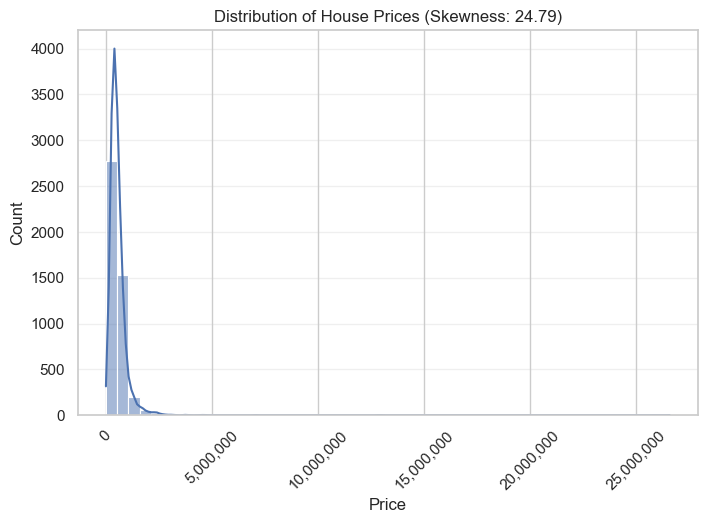

In [6]:
# === 4. Target Variable Analysis (Price) ===

# Calculate Skewness
price_skew = df['price'].skew()
print(f"Skewness of Price: {price_skew:.2f}")

plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=50, kde=True) 

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title(f"Distribution of House Prices (Skewness: {price_skew:.2f})")
plt.xlabel("Price")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

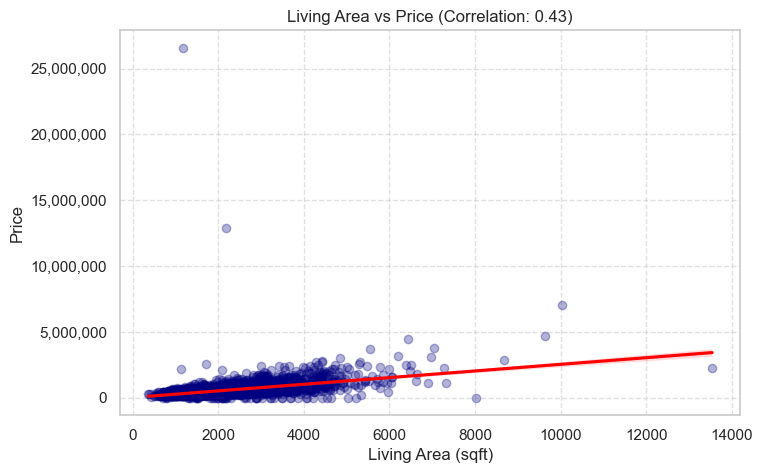

In [7]:
# Living area vs price

# Pearson Correlation
correlation = df['sqft_living'].corr(df['price'])

plt.figure(figsize=(8, 5))
sns.regplot(x="sqft_living", y="price", data=df, 
            scatter_kws={"alpha":0.3, "color":"navy"}, 
            line_kws={"color":"red"}) 

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title(f"Living Area vs Price (Correlation: {correlation:.2f})")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 6. Correlation Analysis

This section examines relationships between numerical variables using a correlation matrix.

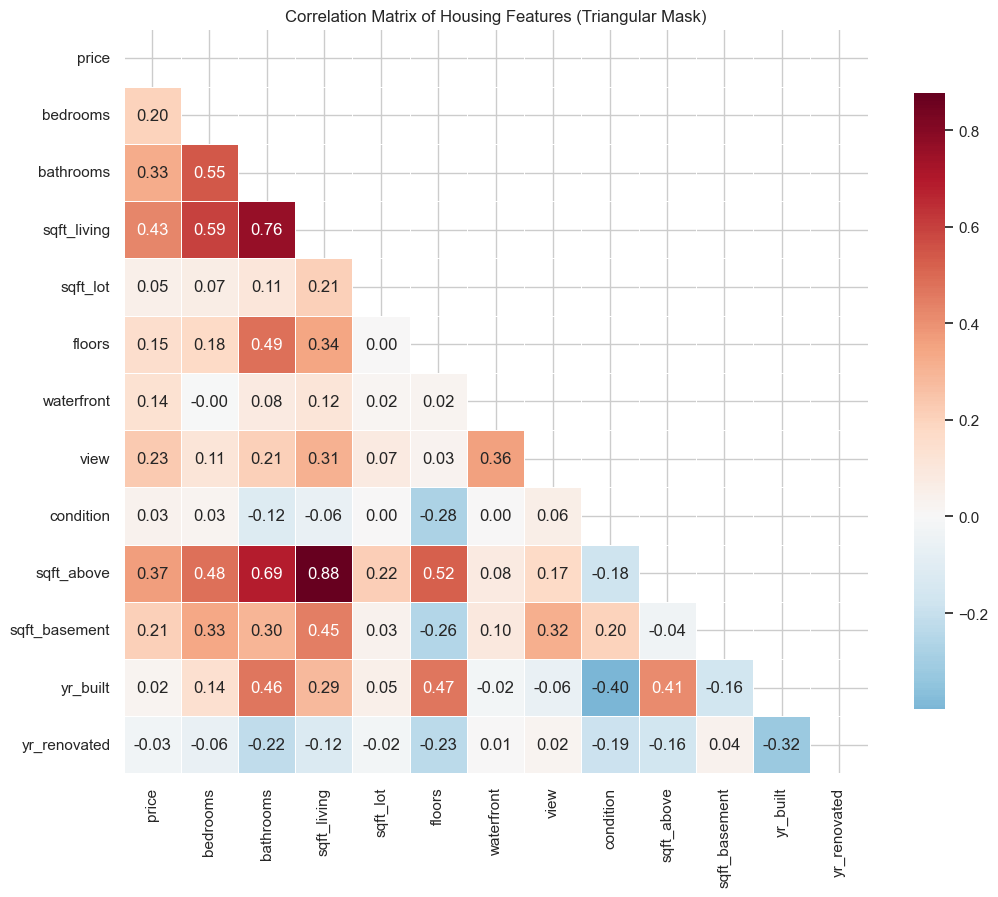

In [ ]:
# Compute correlation matrix
corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r', 
            center=0,
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title("Correlation Matrix of Housing Features (Triangular Mask)")
# plt.savefig("correlation_heatmap.png", bbox_inches='tight') 
plt.show()
# 背景白色
#heat map 右上部分 保留格子，grey

## bedroom bathroom sqft living sqft sqft-basement sqrt above sqrt lot, 
比例特征  sqft living, ratio = above/living 
# featureenginner 完之后
新的 feature heatmap：
1） 每一个 featrure 跟 price 相关性 》 0.2
2） 不同feature之间 没有高相关性


## 7. Feature Exploration

Features are grouped into:
- Structural features (bedrooms, living area)
- Environmental features (waterfront, view)
- Spatial features (city)

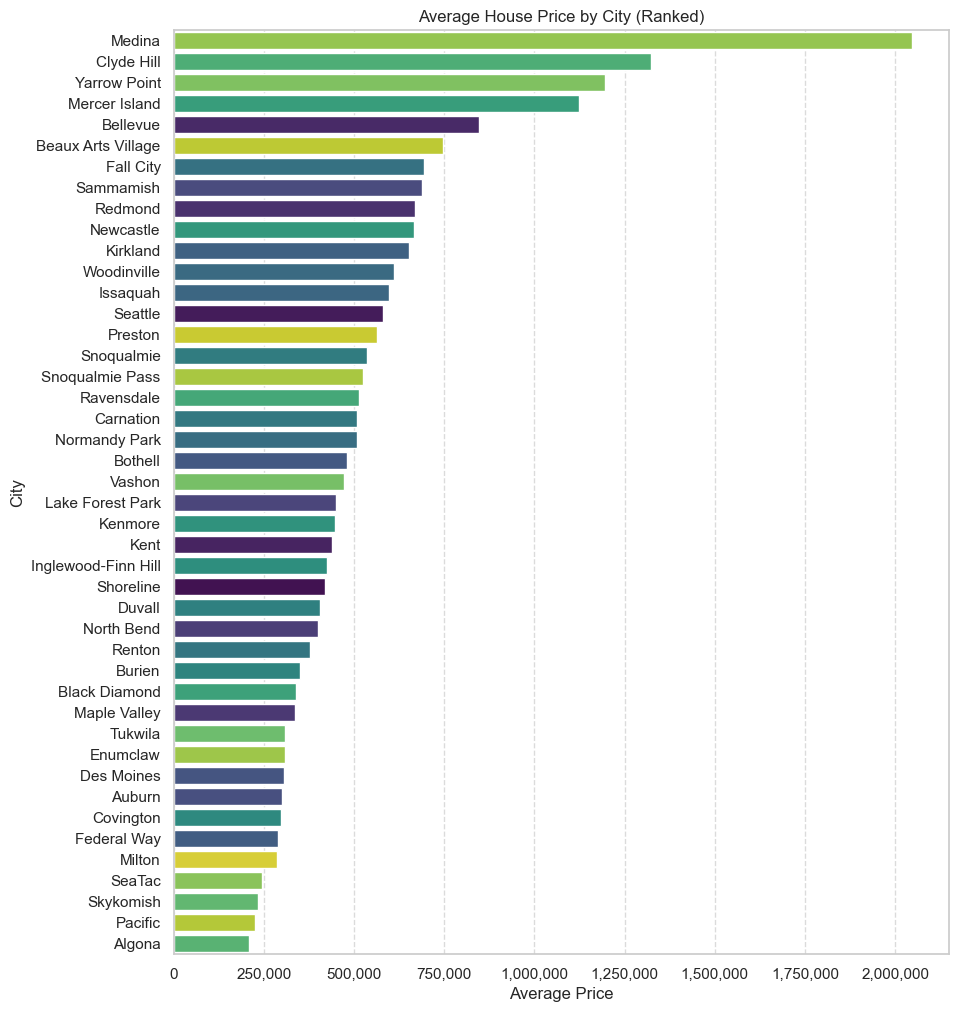

In [8]:
# City vs Price
city_order = df.groupby('city')['price'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 12))
sns.barplot(
    x="price", 
    y="city", 
    data=df, 
    order=city_order, 
    hue="city",          
    palette="viridis", 
    legend=False,        
    estimator=np.mean, 
    errorbar=None
)

from matplotlib.ticker import StrMethodFormatter
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Average House Price by City (Ranked)")
plt.xlabel("Average Price")
plt.ylabel("City")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

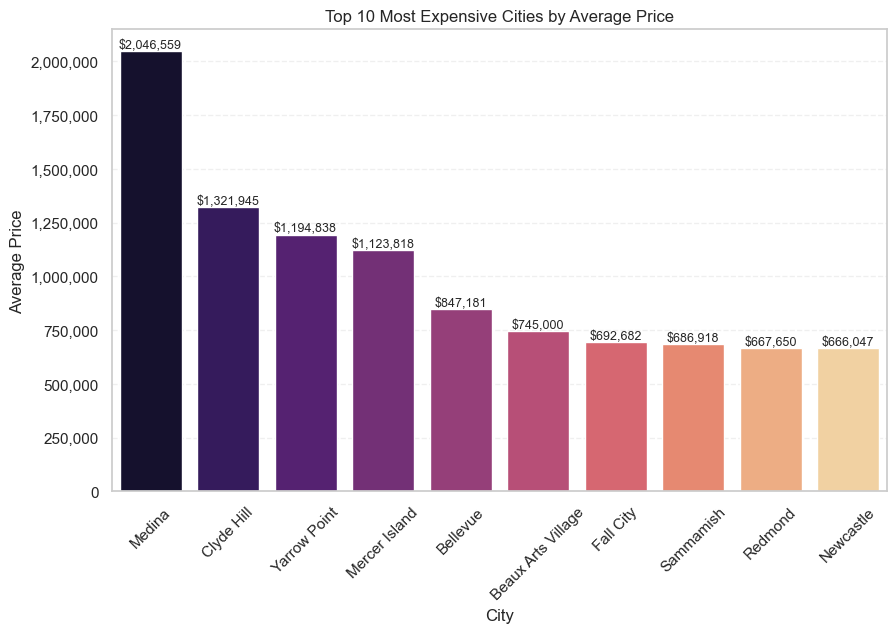

In [9]:
# === 7.1 Deep Dive: Top 10 High-Value Cities ===

top_10_cities = df.groupby("city")["price"].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    x="city", 
    y="price", 
    data=top_10_cities, 
    hue="city", 
    palette="magma", 
    legend=False
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Average/Mean House Price
for i, val in enumerate(top_10_cities['price']):
    plt.text(i, val, f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

plt.title("Top 10 Most Expensive Cities by Average Price")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

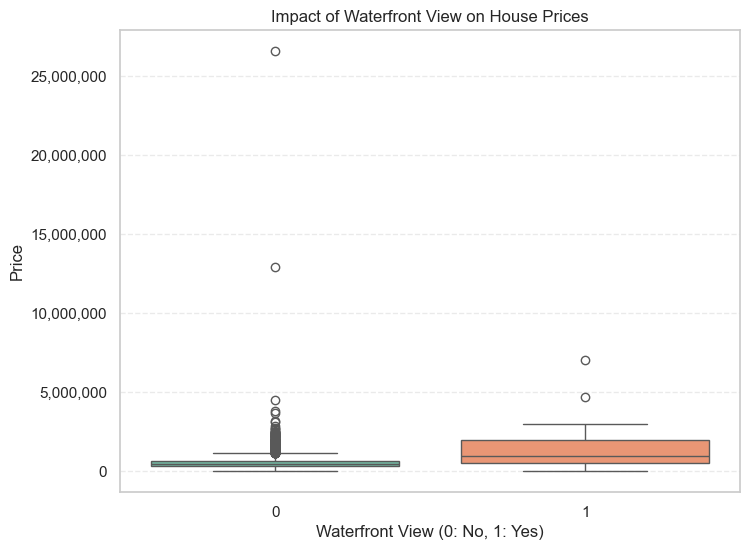

In [10]:
# Waterfront vs Price
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="waterfront", 
    y="price", 
    data=df, 
    hue="waterfront", 
    palette="Set2", 
    legend=False
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Impact of Waterfront View on House Prices")
plt.xlabel("Waterfront View (0: No, 1: Yes)")
plt.ylabel("Price")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

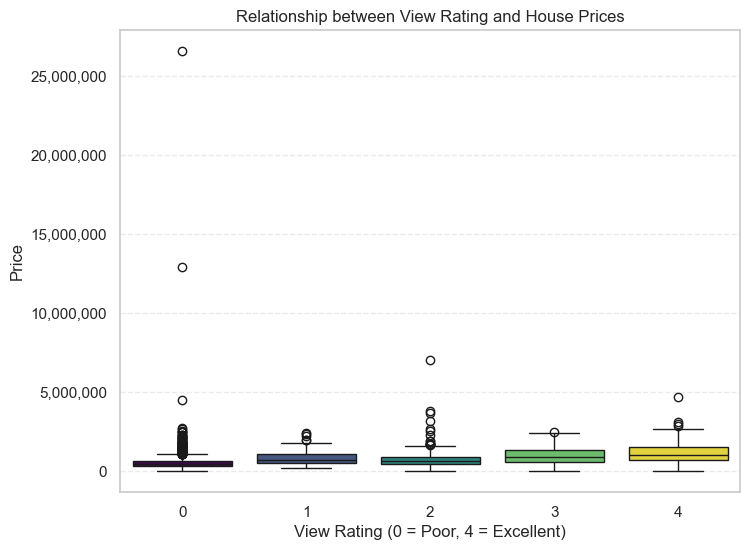

In [11]:
# View vs Price
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="view", 
    y="price", 
    data=df, 
    hue="view", 
    palette="viridis", 
    legend=False
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Relationship between View Rating and House Prices")
plt.xlabel("View Rating (0 = Poor, 4 = Excellent)")
plt.ylabel("Price")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

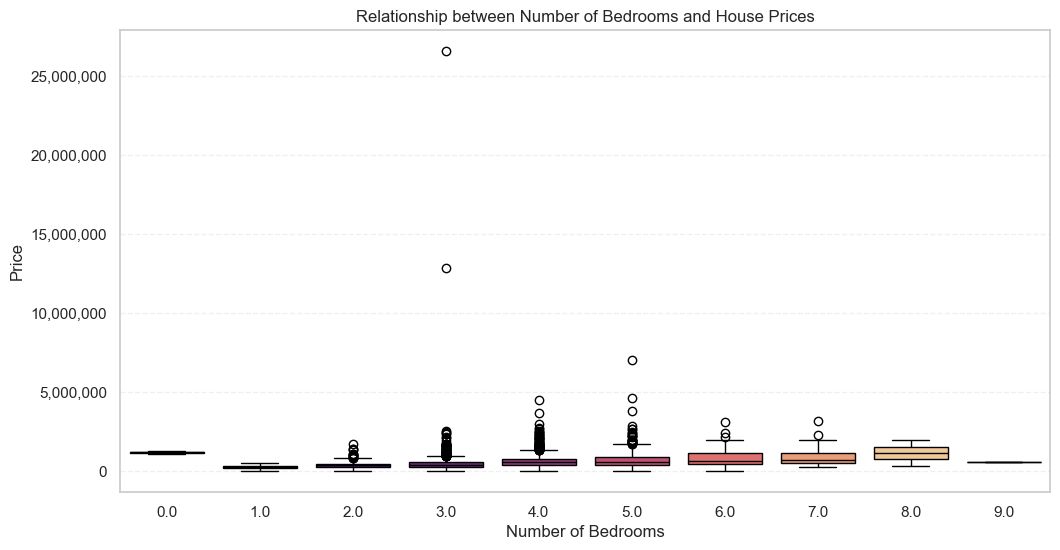

In [12]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x="bedrooms", 
    y="price", 
    data=df, 
    hue="bedrooms", 
    palette="magma", 
    legend=False
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Relationship between Number of Bedrooms and House Prices")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


Removed 17 outlier properties with >6 bedrooms.


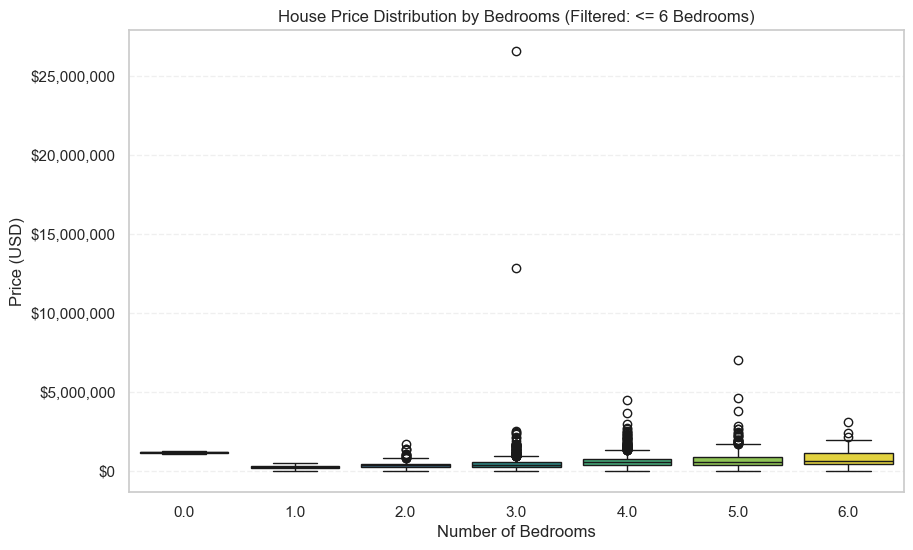

In [13]:
# Bedrooms vs Price (filtered)

limit = 6
df_filtered = df[df['bedrooms'] <= limit]
removed_count = len(df) - len(df_filtered)
print(f"Removed {removed_count} outlier properties with >{limit} bedrooms.")

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="bedrooms", 
    y="price", 
    data=df_filtered, 
    hue="bedrooms", 
    palette="viridis", 
    legend=False
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.title(f"House Price Distribution by Bedrooms (Filtered: <= {limit} Bedrooms)")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price (USD)")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

### Feature Selection

Some variables such as `street` and `country` are removed because:

- `street`: too specific (high cardinality, not generalizable)
- `country`: constant value (no variance, no predictive power)

Removing these features helps simplify the model and reduce noise.

In [ ]:
# Drop irrelevant features
#保留 zipcode; date一个时期
cols_to_drop = ["street", "country", "statezip", "date"]

df_cleaned = df.drop(columns=cols_to_drop, errors="ignore")

print(f"Original features count: {df.shape[1]}")
print(f"Cleaned features count: {df_cleaned.shape[1]}")
print(f"Remaining columns: {df_cleaned.columns.tolist()}")

df_cleaned.head()

Original features count: 18
Cleaned features count: 14
Remaining columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'city']


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond


### Outlier Treatment

The distribution of house prices is highly skewed, with several extreme values.
Outliers may negatively affect model performance, especially for linear models.

Original data size: 4600
After removing outliers: 4360
Number of removed outliers: 240
Percentage removed: 5.22%


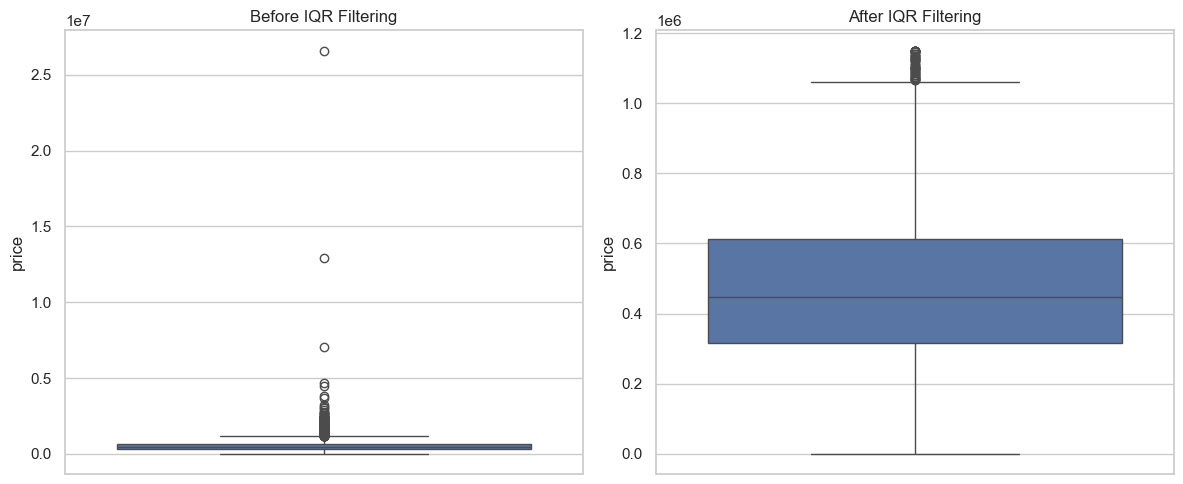

In [ ]:
# Save original size
original_shape = df.shape[0]

# Detect outliers using IQR
# 由于 linear regression 对outlier非常敏感
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter dataset
df_cleaned = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)].copy()

# Calculate removed points
removed = original_shape - df_cleaned.shape[0]

# Print results
print(f"Original data size: {original_shape}")
print(f"After removing outliers: {df_cleaned.shape[0]}")
print(f"Number of removed outliers: {removed}")
print(f"Percentage removed: {removed / original_shape * 100:.2f}%")

# Comparison of the distribution before and after cleaning
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df["price"])
plt.title("Before IQR Filtering")

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned["price"])
plt.title("After IQR Filtering")

plt.tight_layout()
plt.show()

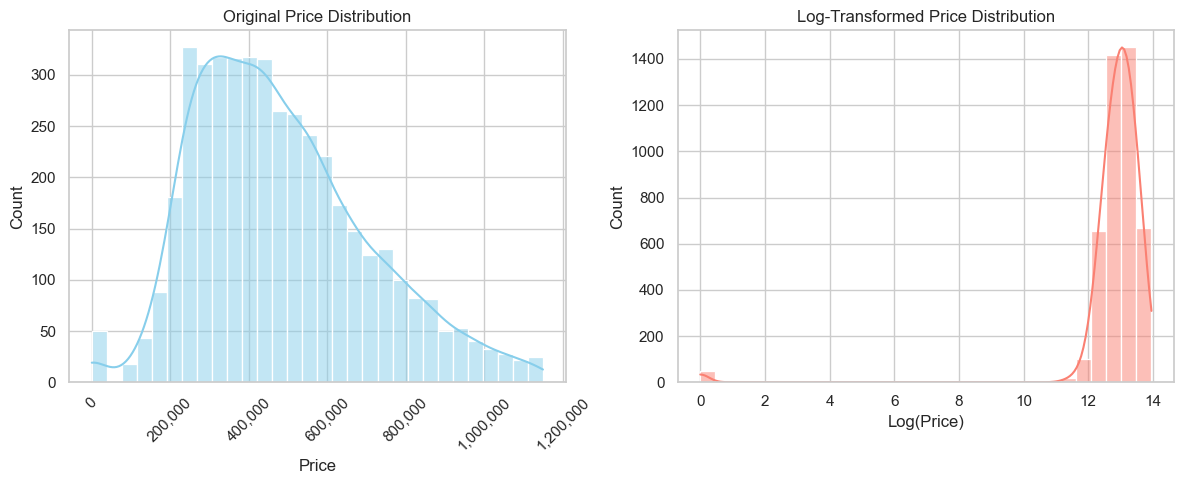

Skewness before: 0.6261498827573944
Skewness after: -7.887665423076715


In [16]:
# Log Transformation Analysis 

# Use cleaned data
df_log = df_cleaned.copy()

# Save original price
original_price = df_log["price"].copy()

# Apply log transformation
df_log["log_price"] = np.log1p(df_log["price"])

# Plot comparison
plt.figure(figsize=(12,5))

# Before
plt.subplot(1,2,1)
sns.histplot(original_price, bins=30, kde=True, color='skyblue') 
plt.title("Original Price Distribution")

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
plt.xlabel("Price")
plt.xticks(rotation=45) 

# After
plt.subplot(1,2,2)
sns.histplot(df_log["log_price"], bins=30, kde=True, color='salmon')
plt.title("Log-Transformed Price Distribution")
plt.xlabel("Log(Price)")

plt.tight_layout()
plt.show()
print("Skewness before:", original_price.skew())
print("Skewness after:", df_log["log_price"].skew())

The distribution of house prices is highly right-skewed. 
After applying a log transformation, the distribution becomes more symmetric and closer to a normal distribution.

This transformation reduces skewness and improves the suitability of the data for regression models.

## Feature Engineering
# 删掉 检查， 只保留engineer， 不需要图
In this section, new features are created to enhance model performance.

- House age is derived from the year built
- A renovation indicator is created
- Seasonal information is extracted from the transaction date

These features aim to capture temporal and structural characteristics that may influence house prices.

In [17]:
# Convert date to datetime
df_cleaned["date"] = pd.to_datetime(df_cleaned["date"])

# Extract year and month
df_cleaned["year"] = df_cleaned["date"].dt.year
df_cleaned["month"] = df_cleaned["date"].dt.month
print(df_cleaned[["year", "month"]].head())

   year  month
0  2014      5
2  2014      5
3  2014      5
4  2014      5
5  2014      5


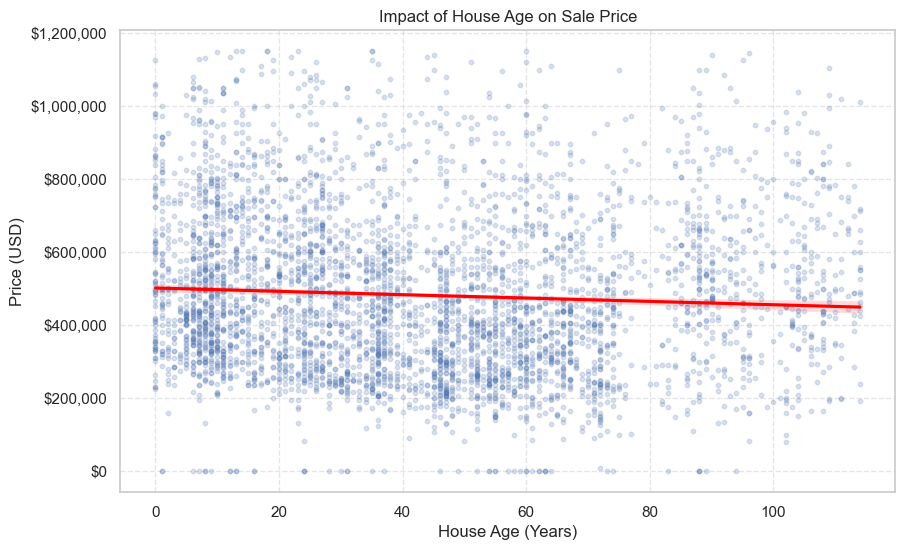

In [18]:
# House age
df_cleaned["house_age"] = df_cleaned["year"] - df_cleaned["yr_built"]

# 2. 检查是否有逻辑错误（例如房龄为负数）
# print(df_cleaned[df_cleaned["house_age"] < 0]) 

plt.figure(figsize=(10, 6))

sns.regplot(
    x="house_age",
    y="price",
    data=df_cleaned,
    scatter_kws={'alpha':0.2, 's':10}, 
    line_kws={'color':'red'}          
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.title("Impact of House Age on Sale Price")
plt.xlabel("House Age (Years)")
plt.ylabel("Price (USD)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

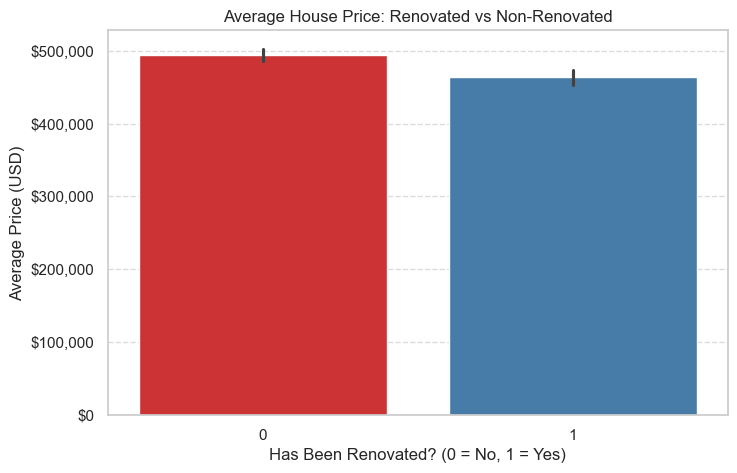

In [19]:
# Renovation indicator
df_cleaned["is_renovated"] = df_cleaned["yr_renovated"].apply(lambda x: 0 if x == 0 else 1)

plt.figure(figsize=(8, 5))

sns.barplot(x="is_renovated", y="price", data=df_cleaned, hue="is_renovated", palette="Set1", legend=False)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.title("Average House Price: Renovated vs Non-Renovated")
plt.xlabel("Has Been Renovated? (0 = No, 1 = Yes)")
plt.ylabel("Average Price (USD)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

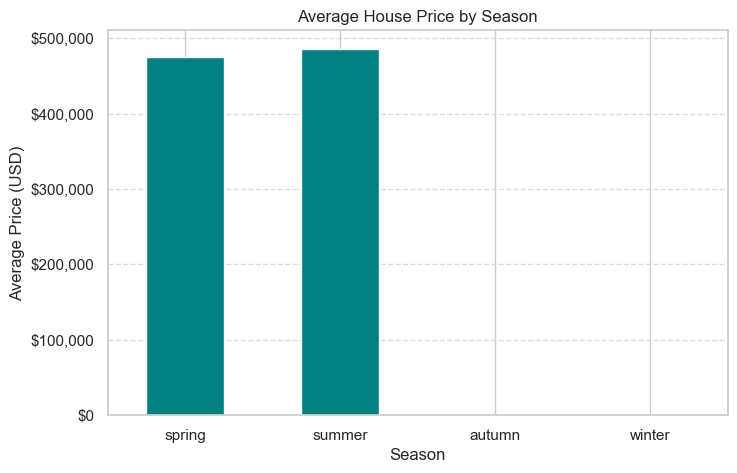

In [ ]:
# Define season -
# 用 1 2 3 4 代替
def get_season(month):
    if month in [12, 1, 2]: return "winter"
    elif month in [3, 4, 5]: return "spring"
    elif month in [6, 7, 8]: return "summer"
    else: return "autumn"

df_cleaned["season"] = df_cleaned["month"].apply(get_season)

season_order = ["spring", "summer", "autumn", "winter"]
seasonal_price = df_cleaned.groupby("season")["price"].mean().reindex(season_order)

plt.figure(figsize=(8, 5))
seasonal_price.plot(kind="bar", color='teal')

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.title("Average House Price by Season")
plt.xlabel("Season")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Note: The dataset only contains spring and summer observations, 
indicating limited temporal coverage.
# 写进discussion

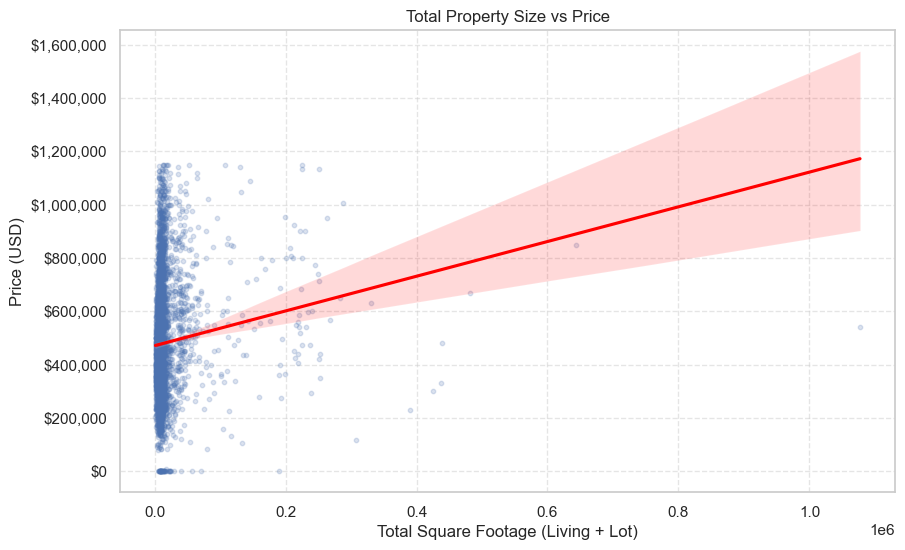

Correlation (Total Sqft): 0.1070
Correlation (Living Sqft Only): 0.5796


In [ ]:
# total square 
# 图需要 放大 主要的那一部分
df_cleaned["total_sqft"] = df_cleaned["sqft_living"] + df_cleaned["sqft_lot"]

plt.figure(figsize=(10, 6))

sns.regplot(
    x="total_sqft",
    y="price",
    data=df_cleaned,
    scatter_kws={"alpha":0.2, "s":10},
    line_kws={"color":"red"}
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.title("Total Property Size vs Price")
plt.xlabel("Total Square Footage (Living + Lot)")
plt.ylabel("Price (USD)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

corr_total = df_cleaned["total_sqft"].corr(df_cleaned["price"])
corr_living = df_cleaned["sqft_living"].corr(df_cleaned["price"])
print(f"Correlation (Total Sqft): {corr_total:.4f}")
print(f"Correlation (Living Sqft Only): {corr_living:.4f}")

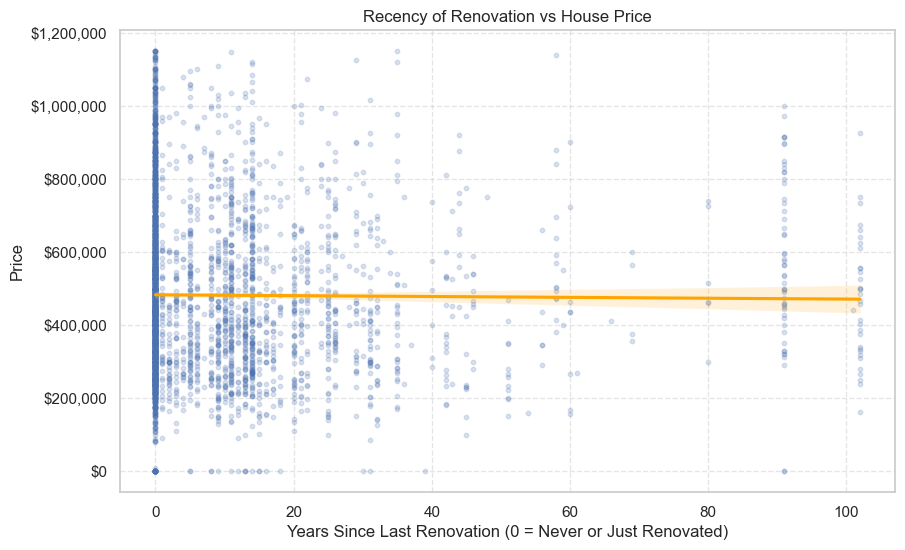

Correlation (Year Since Renovation): -0.0088


In [22]:
# years since renovation
df_cleaned["year_since_renovation"] = np.where(
    df_cleaned["yr_renovated"] == 0, 
    0, 
    df_cleaned["year"] - df_cleaned["yr_renovated"]
)

plt.figure(figsize=(10, 6))
sns.regplot(
    x="year_since_renovation",
    y="price",
    data=df_cleaned,
    scatter_kws={"alpha":0.2, "s":10},
    line_kws={"color":"orange"} 
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.title("Recency of Renovation vs House Price")
plt.xlabel("Years Since Last Renovation (0 = Never or Just Renovated)")
plt.ylabel("Price")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Correlation (Year Since Renovation): {df_cleaned['year_since_renovation'].corr(df_cleaned['price']):.4f}")

### Train-Test Split

The dataset was divided into training and testing sets using an 80/20 split. 
The training set is used to train the models, while the test set is used 
to evaluate their performance on unseen data.

A fixed random seed (random_state=42) is used to ensure reproducibility.

In [23]:
df_model = df_cleaned.copy()
df_model = df_model.drop(columns=['street', 'statezip', 'country', 'date'], errors='ignore')
df_model = pd.get_dummies(df_model, drop_first=True)

# Split features and target
X = df_model.drop(columns=["price", "log_price"], errors="ignore")
y = df_model["price"]

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (3488, 62)
Test size: (872, 62)


In [24]:
irrelevant_strings = ['street', 'statezip', 'country', 'date']

# 2. drop
df_model = df_model.drop(columns=irrelevant_strings, errors='ignore')

# 3. int (0/1)
df_model = df_model.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)

X = df_model.drop(columns=["price", "log_price"], errors="ignore")
y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Remaining features:", X_train.columns.tolist())
print("Non-numeric count:", X_train.select_dtypes(exclude=[np.number]).shape[1])

Remaining features: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'year', 'month', 'house_age', 'is_renovated', 'total_sqft', 'year_since_renovation', 'city_Auburn', 'city_Beaux Arts Village', 'city_Bellevue', 'city_Black Diamond', 'city_Bothell', 'city_Burien', 'city_Carnation', 'city_Clyde Hill', 'city_Covington', 'city_Des Moines', 'city_Duvall', 'city_Enumclaw', 'city_Fall City', 'city_Federal Way', 'city_Inglewood-Finn Hill', 'city_Issaquah', 'city_Kenmore', 'city_Kent', 'city_Kirkland', 'city_Lake Forest Park', 'city_Maple Valley', 'city_Medina', 'city_Mercer Island', 'city_Milton', 'city_Newcastle', 'city_Normandy Park', 'city_North Bend', 'city_Pacific', 'city_Preston', 'city_Ravensdale', 'city_Redmond', 'city_Renton', 'city_Sammamish', 'city_SeaTac', 'city_Seattle', 'city_Shoreline', 'city_Skykomish', 'city_Snoqualmie', 'city_Snoqualmie Pass', 'city_Tukwila', 'city_Va

### Model Evaluation

Four models were evaluated: Linear Regression, Random Forest, XGBoost, and MLP.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

In [27]:
# Hyperparameter Tunin
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid_refined = {
    "n_estimators": [80, 100, 120, 150],
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "max_depth": [4, 5, 6],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

xgb_refined = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

grid_refined = GridSearchCV(
    estimator=xgb_refined,
    param_grid=param_grid_refined,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_refined.fit(X_train, y_train)

best_xgb_refined = grid_refined.best_estimator_

print("Best refined params:", grid_refined.best_params_)
print("Best refined CV RMSE:", -grid_refined.best_score_)

best_xgb = grid_refined.best_estimator_

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
Best refined params: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 120, 'subsample': 0.9}
Best refined CV RMSE: 132325.16379605766


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone

# 5-Fold Out-of-Fold
# Level 1 - base model
base_models = {
    "Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    "XGBoost": best_xgb,
    #"MLP": MLPRegressor(hidden_layer_sizes=(100,50), max_iter=2000, alpha=0.001, random_state=42)
    "MLP": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, alpha=0.001, learning_rate_init=0.001, early_stopping=True, n_iter_no_change=20, random_state=42)
}

results = []

for name, model in base_models.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append([name, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])

print("\n=== Base Model Performance ===")
print(results_df)

# initial
train_oof = np.zeros((X_train.shape[0], len(base_models)))
test_preds = np.zeros((X_test.shape[0], len(base_models)))

# set 5-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# train
for i, (name, model) in enumerate(base_models.items()):
    print(f"Generating OOF for {name}...")
    
    fold_test_preds = np.zeros((X_test.shape[0], 5))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
        
        model_clone = clone(model) 
        
        X_f_train, X_f_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_f_train, y_f_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model_clone.fit(X_f_train, y_f_train)
        
        train_oof[val_idx, i] = model_clone.predict(X_f_val)
        fold_test_preds[:, fold] = model_clone.predict(X_test)
    
    test_preds[:, i] = fold_test_preds.mean(axis=1)

Training Linear...
Training Random Forest...
Training XGBoost...
Training MLP...

=== Base Model Performance ===
           Model           RMSE        R2
0         Linear  142130.512100  0.592289
1  Random Forest  144208.720386  0.580279
2        XGBoost  133399.455267  0.640842
3            MLP  141777.346953  0.594313
Generating OOF for Linear...
Generating OOF for Random Forest...
Generating OOF for XGBoost...
Generating OOF for MLP...


In [29]:
from sklearn.linear_model import Ridge

# Step 1: meta-features
X_meta_train = pd.DataFrame(train_oof, columns=base_models.keys())
X_meta_test = pd.DataFrame(test_preds, columns=base_models.keys())

# Step 2: Passthrough
X_meta_train_full = pd.concat(
    [X_meta_train.reset_index(drop=True), X_train.reset_index(drop=True)],
    axis=1
)

X_meta_test_full = pd.concat(
    [X_meta_test.reset_index(drop=True), X_test.reset_index(drop=True)],
    axis=1
)

# Step 3: Meta-learner（Ridge）
meta_learner = Ridge(alpha=1.0)
meta_learner.fit(X_meta_train_full, y_train)

# Step 4: predict
y_final_pred = meta_learner.predict(X_meta_test_full)

print("Level 2 (Passthrough + Ridge): training successful.")

print("Meta-features (first 5 rows):")
print(X_meta_train_full.head())

final_rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))
final_r2 = r2_score(y_test, y_final_pred)

print("\n=== Final Stacking Performance ===")
print(f"RMSE: {final_rmse:.2f}")
print(f"R2: {final_r2:.4f}")

Level 2 (Passthrough + Ridge): training successful.
Meta-features (first 5 rows):
          Linear  Random Forest       XGBoost            MLP  bedrooms  \
0  253772.342077  276817.717555  290277.31250  291260.025334 -0.428042   
1  476030.253004  352681.538634  441076.90625  434324.618041  0.703026   
2  348882.083963  350624.727283  322017.40625  313845.608152  1.834094   
3  230732.763166  199245.457464  189355.37500  243434.800128 -1.559110   
4  571213.704217  537362.742095  473844.96875  638232.206033  1.834094   

   bathrooms  sqft_living  sqft_lot    floors  waterfront  ...  city_Seattle  \
0  -0.496528    -0.947251 -0.116126 -0.931601   -0.063482  ...     -0.701792   
1  -0.496528     0.037985  4.233406 -0.931601   -0.063482  ...     -0.701792   
2   0.542814     0.203211 -0.152193 -0.931601   -0.063482  ...     -0.701792   
3  -1.535870    -1.522481 -0.210764 -0.931601   -0.063482  ...     -0.701792   
4  -0.150081     0.093060 -0.289975  0.002679   -0.063482  ...      1.424

In [30]:
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display, Markdown

final_rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))
final_r2 = r2_score(y_test, y_final_pred)

display(Markdown("---"))
display(Markdown("#### **Stacking Ensemble Evaluation Results**"))

results_df = pd.DataFrame({
    "Metric": ["Root Mean Squared Error (RMSE)", "R-squared Score ($R^2$)"],
    "Score": [f"${final_rmse:,.2f}", f"{final_r2:.4f}"]
})

display(results_df)

display(Markdown(f"""
> **Discussion:**
> The final model achieved an $R^2$ of **{final_r2:.4f}**. This indicates that our ensemble can explain approximately **{final_r2*100:.1f}%** of the variance in house prices. 
> Compared to the base models, the stacking approach effectively reduced the RMSE by leveraging the strengths of different algorithmic paradigms.
"""))

---

#### **Stacking Ensemble Evaluation Results**

,Metric,Score
0,Root Mean Squared Error (RMSE),"$133,285.69"
1,R-squared Score ($R^2$),0.6415



> **Discussion:**
> The final model achieved an $R^2$ of **0.6415**. This indicates that our ensemble can explain approximately **64.1%** of the variance in house prices. 
> Compared to the base models, the stacking approach effectively reduced the RMSE by leveraging the strengths of different algorithmic paradigms.


 99%|===================| 859/872 [00:26<00:00]        

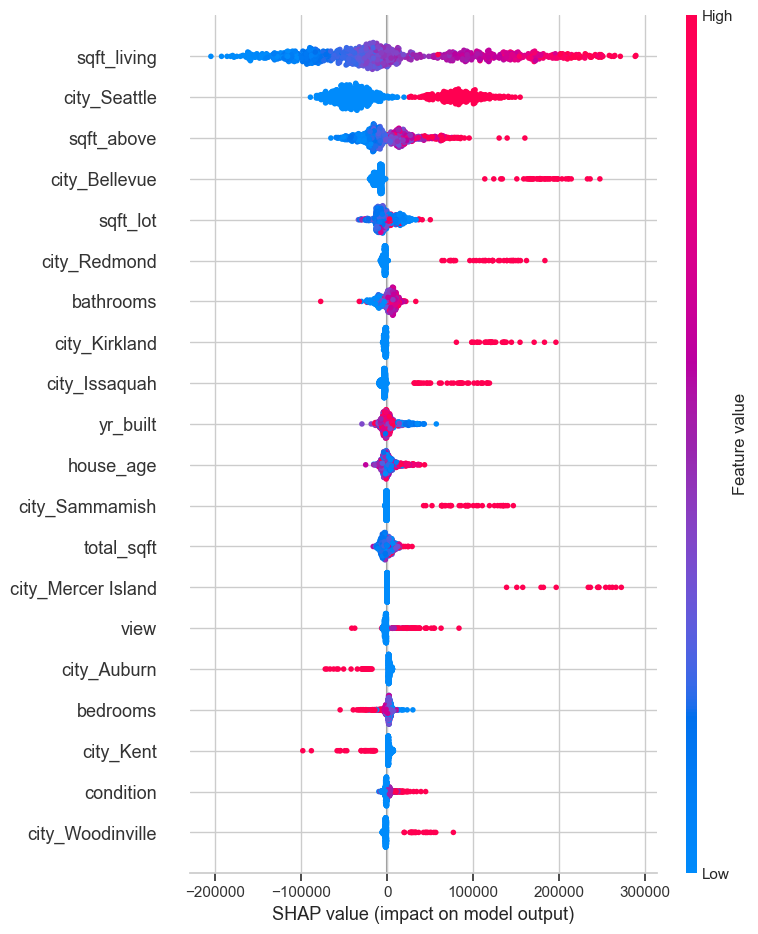

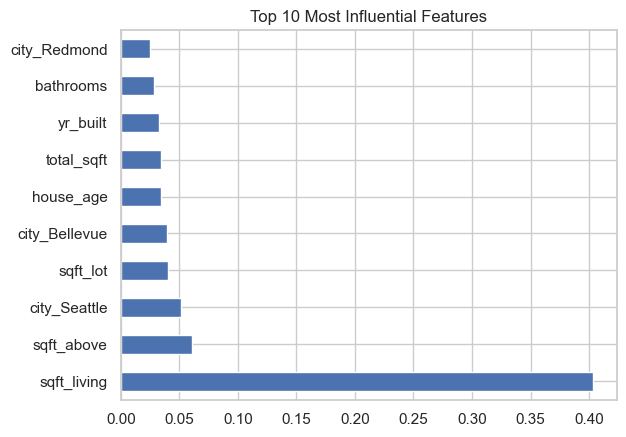

In [31]:
!pip install shap

rf_temp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_temp.fit(X_train, y_train)

import shap

# explainer
explainer = shap.Explainer(rf_temp, X_train)

# SHAP values（test set）
shap_values = explainer(X_test, check_additivity=False)

# Summary plot
shap.summary_plot(shap_values, X_test)

importances = pd.Series(rf_temp.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Most Influential Features")
plt.show()

In [32]:
for name, model in base_models.items():
    print(f"Running CV for {name}...")
    
    try:
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring="neg_root_mean_squared_error"
        )
        print(f"{name} CV RMSE:", -scores.mean())
    
    except Exception as e:
        print(f"{name} FAILED:", e)

Running CV for Linear...
Linear FAILED: name 'cross_val_score' is not defined
Running CV for Random Forest...
Random Forest FAILED: name 'cross_val_score' is not defined
Running CV for XGBoost...
XGBoost FAILED: name 'cross_val_score' is not defined
Running CV for MLP...
MLP FAILED: name 'cross_val_score' is not defined


In [33]:
results.append(["Stacking", final_rmse, final_r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])

print(results_df.sort_values(by="RMSE"))

           Model           RMSE        R2
4       Stacking  133285.694053  0.641454
2        XGBoost  133399.455267  0.640842
3            MLP  141777.346953  0.594313
0         Linear  142130.512100  0.592289
1  Random Forest  144208.720386  0.580279


In [34]:
print("\n=== Ablation Study (Remove One Model) ===")

from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold

ablation_results = []

model_names = list(base_models.keys())

for remove_model in model_names:
    
    print(f"\n--- Removing {remove_model} ---")
    
    # remove one
    ab_models = {k: v for k, v in base_models.items() if k != remove_model}
    
    # initialize
    train_oof_ab = np.zeros((X_train.shape[0], len(ab_models)))
    test_preds_ab = np.zeros((X_test.shape[0], len(ab_models)))
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # OOF
    for i, (name, model) in enumerate(ab_models.items()):
        
        fold_test_preds = np.zeros((X_test.shape[0], 5))
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
            model_clone = clone(model)
            
            X_f_train, X_f_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_f_train, y_f_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model_clone.fit(X_f_train, y_f_train)
            
            train_oof_ab[val_idx, i] = model_clone.predict(X_f_val)
            fold_test_preds[:, fold] = model_clone.predict(X_test)
        
        test_preds_ab[:, i] = fold_test_preds.mean(axis=1)
    
    # meta features
    X_meta_train_ab = pd.DataFrame(train_oof_ab, columns=ab_models.keys())
    X_meta_test_ab = pd.DataFrame(test_preds_ab, columns=ab_models.keys())
    
    X_meta_train_ab_full = pd.concat(
        [X_meta_train_ab.reset_index(drop=True), X_train.reset_index(drop=True)],
        axis=1
    )
    X_meta_test_ab_full = pd.concat(
        [X_meta_test_ab.reset_index(drop=True), X_test.reset_index(drop=True)],
        axis=1
    )
    
    # meta learner
    meta_ab = Ridge(alpha=1.0)
    meta_ab.fit(X_meta_train_ab_full, y_train)
    
    y_pred_ab = meta_ab.predict(X_meta_test_ab_full)
    
    rmse_ab = np.sqrt(mean_squared_error(y_test, y_pred_ab))
    r2_ab = r2_score(y_test, y_pred_ab)
    
    print(f"RMSE: {rmse_ab:.2f}")
    print(f"R2: {r2_ab:.4f}")
    
    ablation_results.append([f"Remove {remove_model}", rmse_ab, r2_ab])


ablation_results.append(["Full Stacking", final_rmse, final_r2])

ablation_df = pd.DataFrame(ablation_results, columns=["Experiment", "RMSE", "R2"])

print("\n=== Ablation Summary ===")
print(ablation_df.sort_values(by="RMSE"))


=== Ablation Study (Remove One Model) ===

--- Removing Linear ---
RMSE: 134867.35
R2: 0.6329

--- Removing Random Forest ---
RMSE: 133475.15
R2: 0.6404

--- Removing XGBoost ---
RMSE: 134740.58
R2: 0.6336

--- Removing MLP ---
RMSE: 133786.21
R2: 0.6388

=== Ablation Summary ===
             Experiment           RMSE        R2
4         Full Stacking  133285.694053  0.641454
1  Remove Random Forest  133475.154467  0.640434
3            Remove MLP  133786.205630  0.638756
2        Remove XGBoost  134740.579420  0.633584
0         Remove Linear  134867.352257  0.632894


Exception ignored in: <function ResourceTracker.__del__ at 0x104ba9800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10747d800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106f4d800>
Traceback (most recent call last